# 03 — Binary Integer Programming for Loan Approval Optimization

**Author:** Shuxin Dong  
**Project:** Math 586 — Loan Approval Optimization  
**Input:**  `data/processed/loans_with_profit.csv` (from notebook 02)  
**Output:** `data/processed/loans_with_decisions.csv`


## Mathematical formulation

**Decision variables**:
$$x_i \in \{0, 1\}, \quad i = 1, \ldots, N$$
where $x_i = 1$ means loan $i$ is approved.

**Objective** (maximize expected portfolio profit):
$$\max \sum_{i=1}^{N} x_i \, \pi_i$$

**Constraints**:
1. Capital budget: $\sum_i x_i A_i \le B$
2. Portfolio risk: $\frac{\sum_i x_i A_i \cdot PD_i}{\sum_i x_i A_i} \le \bar{p}$
   (linearized as $\sum_i x_i A_i (PD_i - \bar{p}) \le 0$)
3. Concentration by purpose: $\sum_{i \in \text{purpose }k} x_i A_i \le \alpha \sum_i x_i A_i$ for each $k$
   (linearized as $\sum_{i \in k} x_i A_i - \alpha \sum_i x_i A_i \le 0$)


## 1. Imports and paths

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pulp
from pathlib import Path
import time

PROJECT_ROOT = Path.cwd().parent
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PROFIT_PATH = PROCESSED_DIR / "loans_with_profit.csv"
DECISIONS_PATH = PROCESSED_DIR / "loans_with_decisions.csv"

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

print(f"PuLP version: {pulp.__version__}")
print(f"Available solvers: {pulp.listSolvers(onlyAvailable=True)}")
print(f"Input:  {PROFIT_PATH}  (exists: {PROFIT_PATH.exists()})")
print(f"Output: {DECISIONS_PATH}")

PuLP version: 3.3.0
Available solvers: ['PULP_CBC_CMD']
Input:  /Users/dongshuxin/Desktop/Banking Project/data/processed/loans_with_profit.csv  (exists: True)
Output: /Users/dongshuxin/Desktop/Banking Project/data/processed/loans_with_decisions.csv


## 2. Load profit data

In [2]:
df = pd.read_csv(PROFIT_PATH)
print(f"Shape: {df.shape}")
print(f"\nKey columns we need:")
for c in ["id", "loan_amnt", "pd_calibrated", "pi", "target_default", "purpose", "grade"]:
    if c in df.columns:
        print(f"  ✓ {c}")
    else:
        print(f"  ✗ {c} — MISSING")

print(f"\nQuick stats on pi:")
print(f"  count > 0:   {(df['pi'] > 0).sum():,}")
print(f"  count <= 0:  {(df['pi'] <= 0).sum():,}")
print(f"  total pi:    ${df['pi'].sum():,.0f}")
print(f"  total pi (only positive): ${df.loc[df['pi'] > 0, 'pi'].sum():,.0f}")

Shape: (169321, 31)

Key columns we need:
  ✓ id
  ✓ loan_amnt
  ✓ pd_calibrated
  ✓ pi
  ✓ target_default
  ✓ purpose
  ✓ grade

Quick stats on pi:
  count > 0:   86,419
  count <= 0:  82,902
  total pi:    $72,961,378
  total pi (only positive): $112,939,580


## 3. Set optimization parameters

These are the levers the institution would pull when running the optimization. We pick reasonable starting values for notebook 03 and explore their sensitivity in notebook 04.

| Parameter | Value | Reasoning |
|---|---|---|
| `BUDGET` | $1.5B | About 62% of the total $2.42B that approving every loan would require. Forces the optimizer to be selective. |
| `MAX_PORTFOLIO_PD` | 0.20 | Portfolio-weighted PD must stay at or below 20%, slightly tighter than the 23.13% "approve all" baseline. |
| `MAX_PURPOSE_SHARE` | 0.30 | No single loan purpose may exceed 30% of total approved volume. Diversification rule. |

In [3]:
OPT_PARAMS = {
    "BUDGET":            1_500_000_000,  # $1.5B capital budget
    "MAX_PORTFOLIO_PD":  0.20,            # weighted-average PD ≤ 0.20
    "MAX_PURPOSE_SHARE": 0.30,            # any single purpose ≤ 30% of approved volume
}

# Reference numbers (what "approve all" would look like)
total_amount_all = df["loan_amnt"].sum()
weighted_pd_all = (df["pd_calibrated"] * df["loan_amnt"]).sum() / total_amount_all
purpose_shares_all = df.groupby("purpose")["loan_amnt"].sum() / total_amount_all

print("OPTIMIZATION PARAMETERS:")
for k, v in OPT_PARAMS.items():
    if isinstance(v, (int, float)) and v >= 1000:
        print(f"  {k:25s} = ${v:,.0f}")
    else:
        print(f"  {k:25s} = {v}")

print(f"\nREFERENCE (approve-all baseline):")
print(f"  Total loan volume:        ${total_amount_all:,.0f}")
print(f"  Budget as fraction:       {OPT_PARAMS['BUDGET']/total_amount_all*100:.1f}% of total")
print(f"  Weighted-avg PD:          {weighted_pd_all:.4f}")
print(f"  Top-3 purpose shares:")
for p, s in purpose_shares_all.sort_values(ascending=False).head(3).items():
    print(f"    {p:25s} {s*100:5.1f}%")

OPTIMIZATION PARAMETERS:
  BUDGET                    = $1,500,000,000
  MAX_PORTFOLIO_PD          = 0.2
  MAX_PURPOSE_SHARE         = 0.3

REFERENCE (approve-all baseline):
  Total loan volume:        $2,421,502,475
  Budget as fraction:       61.9% of total
  Weighted-avg PD:          0.2536
  Top-3 purpose shares:
    debt_consolidation         60.6%
    credit_card                19.0%
    home_improvement            8.1%


## 4. Build the BIP model

We construct the PuLP `LpProblem`, add 169,321 binary variables, set the objective, and add all constraints. We do **not** solve yet — building takes ~30 seconds, solving will be its own step.

In [4]:
# Reset index so positional access matches the variable list
df = df.reset_index(drop=True)
n = len(df)

# Pre-extract numpy arrays for speed
loan_amnt = df["loan_amnt"].values
pd_cal = df["pd_calibrated"].values
pi = df["pi"].values
purposes = df["purpose"].values
unique_purposes = df["purpose"].unique()

print(f"Building BIP for {n:,} loans across {len(unique_purposes)} purpose categories...")
t0 = time.time()

# Initialize problem
prob = pulp.LpProblem("LoanApproval", pulp.LpMaximize)

# Binary decision variables
x = [pulp.LpVariable(f"x_{i}", cat="Binary") for i in range(n)]

# Objective
prob += pulp.lpSum([pi[i] * x[i] for i in range(n)]), "TotalExpectedProfit"

# Constraint 1: Capital budget
prob += pulp.lpSum([loan_amnt[i] * x[i] for i in range(n)]) <= OPT_PARAMS["BUDGET"], "CapitalBudget"

# Constraint 2: Portfolio PD (linearized)
# Σ x_i A_i (PD_i - p_bar) ≤ 0
p_bar = OPT_PARAMS["MAX_PORTFOLIO_PD"]
prob += pulp.lpSum([loan_amnt[i] * (pd_cal[i] - p_bar) * x[i] for i in range(n)]) <= 0, "PortfolioPD"

# Constraint 3: Purpose concentration (one constraint per purpose, linearized)
# Σ_{i in k} x_i A_i - α Σ_i x_i A_i ≤ 0
alpha = OPT_PARAMS["MAX_PURPOSE_SHARE"]
for k, purp in enumerate(unique_purposes):
    in_purp = (purposes == purp)
    prob += (
        pulp.lpSum([loan_amnt[i] * x[i] for i in range(n) if in_purp[i]])
        - alpha * pulp.lpSum([loan_amnt[i] * x[i] for i in range(n)])
    ) <= 0, f"Concentration_{purp}"

build_time = time.time() - t0
print(f"Model built in {build_time:.1f}s")
print(f"  Variables:    {len(prob.variables()):,}")
print(f"  Constraints:  {len(prob.constraints):,}")

Building BIP for 169,321 loans across 12 purpose categories...
Model built in 19.9s
  Variables:    169,321
  Constraints:  14


## 5. Solve

**Expected runtime:** anywhere from 2 to 30 minutes depending on the laptop. CBC will print intermediate progress in the terminal output. If after 30 minutes there is no solution, interrupt and we'll downsample.

We pass `timeLimit=1800` (30-minute cap) and `msg=True` so we can see CBC's progress.

In [5]:
solver = pulp.PULP_CBC_CMD(msg=True, timeLimit=1800)

print("Solving... (this may take several minutes)")
t0 = time.time()
status = prob.solve(solver)
solve_time = time.time() - t0

print(f"\n=== SOLVE COMPLETE ===")
print(f"Status:        {pulp.LpStatus[status]}")
print(f"Solve time:    {solve_time:.1f}s ({solve_time/60:.1f} min)")
if status == 1:
    print(f"Objective:     ${pulp.value(prob.objective):,.0f}")
else:
    print("⚠ No optimal solution found within time limit. Best feasible solution will be used.")

Solving... (this may take several minutes)
Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/dongshuxin/Desktop/Banking Project/venv/lib/python3.12/site-packages/pulp/apis/../solverdir/cbc/osx/i64/cbc /var/folders/z0/d64_q4qn77q1mpsgslcw2cjh0000gn/T/220919a9cb7e42d695d123ba01bbaef7-pulp.mps -max -sec 1800 -timeMode elapsed -branch -printingOptions all -solution /var/folders/z0/d64_q4qn77q1mpsgslcw2cjh0000gn/T/220919a9cb7e42d695d123ba01bbaef7-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 19 COLUMNS
At line 2878477 RHS
At line 2878492 BOUNDS
At line 3047814 ENDATA
Problem MODEL has 14 rows, 169321 columns and 2370494 elements
Coin0008I MODEL read with 0 errors
seconds was changed from 1e+100 to 1800
Option for timeMode changed from cpu to elapsed
Continuous objective value is 8.21169e+07 - 6.16 seconds
Cgl0004I processed model has 14 rows, 155694 columns (155694 integer (144368 of which binary)) and 21797

In [6]:
# Extract decision variables back into the dataframe
decisions = np.array([int(round(x[i].value())) if x[i].value() is not None else 0 for i in range(n)])
df["approve_bip"] = decisions

n_approved = int(decisions.sum())
print(f"BIP solution summary:")
print(f"  Loans approved:          {n_approved:,}  ({n_approved/n*100:.1f}%)")
print(f"  Loans rejected:          {n-n_approved:,}")
print(f"  Total approved volume:   ${(df['loan_amnt']*df['approve_bip']).sum():,.0f}")
print(f"  Budget utilization:      {(df['loan_amnt']*df['approve_bip']).sum()/OPT_PARAMS['BUDGET']*100:.1f}%")

approved = df[df["approve_bip"] == 1]
if len(approved) > 0:
    wpd = (approved["pd_calibrated"] * approved["loan_amnt"]).sum() / approved["loan_amnt"].sum()
    print(f"  Weighted-avg PD (vs cap of {OPT_PARAMS['MAX_PORTFOLIO_PD']:.2f}):  {wpd:.4f}")
    print(f"  Total expected profit:   ${approved['pi'].sum():,.0f}")
    print(f"  Total realized profit*:  ${(approved['pi']).sum():,.0f}  (computed below using actual outcomes)")

BIP solution summary:
  Loans approved:          65,019  (38.4%)
  Loans rejected:          104,302
  Total approved volume:   $935,093,675
  Budget utilization:      62.3%
  Weighted-avg PD (vs cap of 0.20):  0.2000
  Total expected profit:   $82,116,893
  Total realized profit*:  $82,116,893  (computed below using actual outcomes)


## 6. Compute three benchmark strategies

We compare the BIP solution against two simpler approaches:

- **Strategy A (Approve All)**: approve every loan in the data — this represents what LendingClub already did.
- **Strategy B (PD Threshold)**: approve loans whose calibrated PD is below 0.30. A simple, transparent rule that any analyst could implement.
- **Strategy C (BIP Optimal)**: the BIP solution from above.

For each strategy we record approval rate, default rate, total profit (expected and realized), and ROI.

In [7]:
# Define the three approve flags as 0/1 columns
df["approve_all"] = 1
df["approve_threshold"] = (df["pd_calibrated"] < 0.30).astype(int)
# approve_bip already exists

def evaluate(df, approve_col, label):
    sub = df[df[approve_col] == 1]
    if len(sub) == 0:
        return {"strategy": label, "n_approved": 0}
    n_app = len(sub)
    vol = sub["loan_amnt"].sum()
    # Realized profit: for non-defaulters, get net_income_good; for defaulters, lose LGD*EAD
    # We approximate using pi but conditioned on actual outcome
    realized_per_loan = np.where(
        sub["target_default"] == 0,
        sub["net_income_good"] - 200.0,         # good: net income minus origination fee
        -0.9013 * sub["ead"] - 200.0,             # bad: lose LGD * EAD plus origination fee
    )
    return {
        "strategy": label,
        "n_approved": n_app,
        "approval_rate": n_app / len(df) * 100,
        "total_volume": vol,
        "avg_pd": (sub["pd_calibrated"] * sub["loan_amnt"]).sum() / vol,
        "actual_default_rate": sub["target_default"].mean() * 100,
        "expected_profit": sub["pi"].sum(),
        "realized_profit": realized_per_loan.sum(),
        "roi_expected_pct": sub["pi"].sum() / vol * 100,
        "roi_realized_pct": realized_per_loan.sum() / vol * 100,
    }

results = pd.DataFrame([
    evaluate(df, "approve_all",       "A. Approve All"),
    evaluate(df, "approve_threshold", "B. PD Threshold (<0.30)"),
    evaluate(df, "approve_bip",       "C. BIP Optimal"),
])

# Pretty print
display_df = results.copy()
for c in ["total_volume", "expected_profit", "realized_profit"]:
    display_df[c] = display_df[c].apply(lambda v: f"${v:,.0f}")
for c in ["approval_rate", "actual_default_rate", "roi_expected_pct", "roi_realized_pct"]:
    display_df[c] = display_df[c].apply(lambda v: f"{v:.2f}%")
display_df["avg_pd"] = display_df["avg_pd"].apply(lambda v: f"{v:.4f}")
display_df["n_approved"] = display_df["n_approved"].apply(lambda v: f"{v:,}")

print("COMPARISON OF THREE STRATEGIES")
print("=" * 100)
print(display_df.T.to_string())

COMPARISON OF THREE STRATEGIES
                                  0                        1               2
strategy             A. Approve All  B. PD Threshold (<0.30)  C. BIP Optimal
n_approved                  169,321                  121,036          65,019
approval_rate               100.00%                   71.48%          38.40%
total_volume         $2,421,502,475           $1,535,167,825    $935,093,675
avg_pd                       0.2536                   0.1721          0.2000
actual_default_rate          23.13%                   16.93%          20.25%
expected_profit         $72,961,378              $40,003,477     $82,116,893
realized_profit         $64,405,335              $31,313,440     $62,439,665
roi_expected_pct              3.01%                    2.61%           8.78%
roi_realized_pct              2.66%                    2.04%           6.68%


## 7. Visualizations

Four panels make the comparison vivid:

1. **Approval rates** — how selective is each strategy?
2. **Realized default rate** — does selection actually reduce defaults?
3. **Realized profit** — bottom line
4. **ROI** — profit per dollar lent

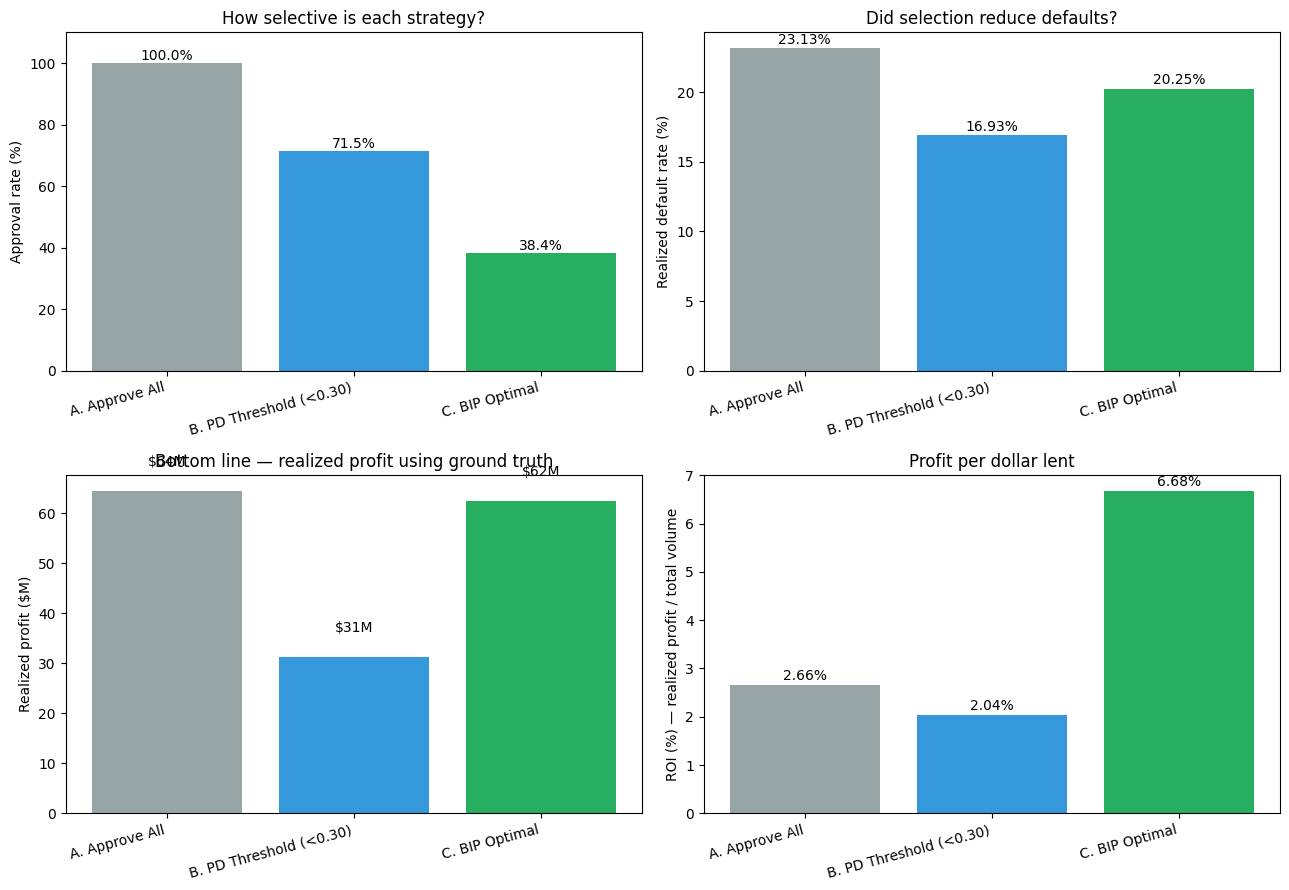

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
labels = results["strategy"].tolist()
x_pos = np.arange(len(labels))
colors = ["#95a5a6", "#3498db", "#27ae60"]  # gray, blue, green

# Panel 1: approval rate
axes[0, 0].bar(x_pos, results["approval_rate"], color=colors)
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels(labels, rotation=15, ha="right")
axes[0, 0].set_ylabel("Approval rate (%)")
axes[0, 0].set_title("How selective is each strategy?")
for i, v in enumerate(results["approval_rate"]):
    axes[0, 0].text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=10)
axes[0, 0].set_ylim(0, 110)

# Panel 2: realized default rate
axes[0, 1].bar(x_pos, results["actual_default_rate"], color=colors)
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(labels, rotation=15, ha="right")
axes[0, 1].set_ylabel("Realized default rate (%)")
axes[0, 1].set_title("Did selection reduce defaults?")
for i, v in enumerate(results["actual_default_rate"]):
    axes[0, 1].text(i, v + 0.3, f"{v:.2f}%", ha="center", fontsize=10)

# Panel 3: realized profit
axes[1, 0].bar(x_pos, results["realized_profit"] / 1e6, color=colors)
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(labels, rotation=15, ha="right")
axes[1, 0].set_ylabel("Realized profit ($M)")
axes[1, 0].set_title("Bottom line — realized profit using ground truth")
for i, v in enumerate(results["realized_profit"]):
    axes[1, 0].text(i, v / 1e6 + 5, f"${v/1e6:.0f}M", ha="center", fontsize=10)

# Panel 4: ROI
axes[1, 1].bar(x_pos, results["roi_realized_pct"], color=colors)
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(labels, rotation=15, ha="right")
axes[1, 1].set_ylabel("ROI (%) — realized profit / total volume")
axes[1, 1].set_title("Profit per dollar lent")
for i, v in enumerate(results["roi_realized_pct"]):
    axes[1, 1].text(i, v + 0.1, f"{v:.2f}%", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "strategy_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

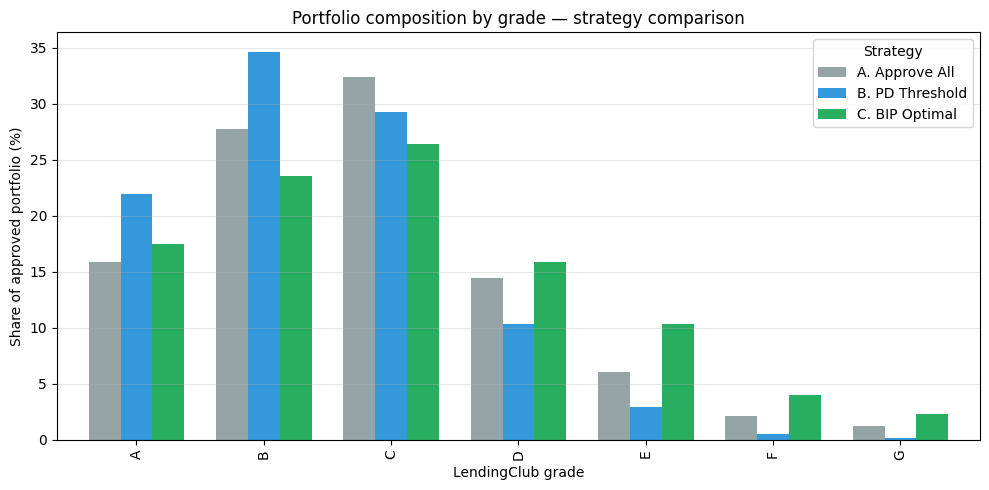

Portfolio composition (% of approved loans, by grade):
       A. Approve All  B. PD Threshold  C. BIP Optimal
grade                                                 
A                15.9             22.0            17.5
B                27.8             34.7            23.6
C                32.4             29.3            26.4
D                14.5             10.4            15.8
E                 6.0              3.0            10.3
F                 2.2              0.5             4.0
G                 1.3              0.2             2.3


In [9]:
# Composition by grade — which strategy picks which borrowers?
comp = []
for col, label in [("approve_all", "A. Approve All"),
                    ("approve_threshold", "B. PD Threshold"),
                    ("approve_bip", "C. BIP Optimal")]:
    sub = df[df[col] == 1]
    g = sub.groupby("grade", observed=True).size() / len(sub) * 100
    comp.append(g.rename(label))
comp_df = pd.concat(comp, axis=1).fillna(0).sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
comp_df.plot(kind="bar", ax=ax,
              color=["#95a5a6", "#3498db", "#27ae60"], width=0.75)
ax.set_xlabel("LendingClub grade")
ax.set_ylabel("Share of approved portfolio (%)")
ax.set_title("Portfolio composition by grade — strategy comparison")
ax.legend(title="Strategy")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "composition_by_grade.png", dpi=150, bbox_inches="tight")
plt.show()

print("Portfolio composition (% of approved loans, by grade):")
print(comp_df.round(1).to_string())

## 8. Save the dataset with all decisions

We save a single CSV containing every loan with three approval columns (`approve_all`, `approve_threshold`, `approve_bip`). Notebook 04 will use this to do sensitivity analysis.

In [10]:
df.to_csv(DECISIONS_PATH, index=False)
print(f"Saved to: {DECISIONS_PATH}")
print(f"Shape: {df.shape}")
print(f"File size: {DECISIONS_PATH.stat().st_size / 1e6:.1f} MB")

# Also save the strategy comparison results table for the report
results.to_csv(OUTPUTS_DIR / "strategy_comparison.csv", index=False)
print(f"\nStrategy comparison table saved to: {OUTPUTS_DIR / 'strategy_comparison.csv'}")

Saved to: /Users/dongshuxin/Desktop/Banking Project/data/processed/loans_with_decisions.csv
Shape: (169321, 34)
File size: 50.6 MB

Strategy comparison table saved to: /Users/dongshuxin/Desktop/Banking Project/outputs/strategy_comparison.csv
